# Analogy Type Classification
This notebook classifies the analogy type for each record in the SCAR dataset using DSPy and the easy_llm_importer.

- According to Bejar, Chaffin & Embretson (1991) we use his analogy types.
- With tweaks to suit the system analogies rather than the word analogies it was considering at first.




In [ ]:
import sys
import os
import pandas as pd
import ast
from pathlib import Path

# Get the notebook's directory and project root
# In Jupyter, __file__ is not available, so we use Path.cwd()
# The notebook should be run from its directory or project root
notebook_dir = Path.cwd()

# Find project root (should contain 'dataset' directory and 'utils')
project_root = notebook_dir
max_iterations = 10  # Safety limit
iteration = 0
while project_root != project_root.parent and iteration < max_iterations:
    if (project_root / "dataset").exists() and (project_root / "utils").exists():
        break
    project_root = project_root.parent
    iteration += 1

# Add utils directory to path to import easy_llm_importer
utils_dir = project_root / "utils"
if utils_dir.exists() and str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

from easy_llm_importer import LLMClient, DSPyAdapter
import dspy

print("✅ Imports successful")
print(f"📁 Project root: {project_root}")
print(f"📁 Utils directory: {utils_dir}")


✅ Imports successful
📁 Project root: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies
📁 Mapping directory: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage1_analysis\mapping_generation


In [ ]:
# Load SCAR dataset
# Use project root to find data file
if 'project_root' in globals():
    data_path = project_root / "dataset" / "SCAR_cleaned_manually.csv"
else:
    # Fallback: try relative path
    notebook_dir = Path.cwd()
    project_root = notebook_dir
    while project_root != project_root.parent:
        if (project_root / "dataset").exists():
            break
        project_root = project_root.parent
    data_path = project_root / "dataset" / "SCAR_cleaned_manually.csv"

df_scar = pd.read_csv(data_path)
print(f"📁 Data loaded from: {data_path}")

# Parse mappings and explanations
df_scar['mappings_list'] = df_scar['mappings_parsed'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and x else []
)
df_scar['explanation_list'] = df_scar['explanation_parsed'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and x else []
)

print(f"✅ Loaded {len(df_scar)} SCAR records")
print(f"\nColumns: {list(df_scar.columns)}")
df_scar.head()


📁 Data loaded from: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\data\SCAR_cleaned_manually.csv
✅ Loaded 400 SCAR records

Columns: ['id', 'system_a', 'system_b', 'system_a_domain', 'system_b_domain', 'system_a_background', 'system_b_background', 'mappings_parsed', 'mapping_count', 'explanation_parsed', 'explanation_count', 'system_a_bg_wc', 'system_b_bg_wc', 'mappings_list', 'explanation_list']


,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc,mappings_list,explanation_list
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118,"[[changes, pointer], [state, time], [adjust, m...",[Changes correspond to pointers: In the biolog...
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149,"[[biology, books], [biodiversity, Book Type], ...",[Biology corresponds to books: In the biospher...
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143,"[[oxygen, fuel], [the lungs, combustion chambe...",[Oxygen corresponds to fuel: In the respirator...
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170,"[[pathogen, fire], [crowd, combustibles], [Pre...",[Pathogens correspond to fire: in the transmis...
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130,"[[Gene, raw material], [CRISPR-Cas9 Technology...",[Gene corresponds to raw materials: in gene ed...


In [3]:
def format_scar_record(record):
    """
    Format a SCAR record into a string representation for the prompt.
    
    Args:
        record: pandas Series or dict containing SCAR record fields
        
    Returns:
        Formatted string representation of the record
    """
    # Extract fields
    system_a = record.get('system_a', '')
    system_b = record.get('system_b', '')
    system_a_bg = record.get('system_a_background', '')
    system_b_bg = record.get('system_b_background', '')
    
    # Get mappings (handle both parsed list and string)
    mappings = record.get('mappings_list', [])
    if not mappings and 'mappings_parsed' in record:
        try:
            mappings = ast.literal_eval(record['mappings_parsed']) if pd.notna(record['mappings_parsed']) else []
        except:
            mappings = []
    
    # Get explanations (handle both parsed list and string)
    explanations = record.get('explanation_list', [])
    if not explanations and 'explanation_parsed' in record:
        try:
            explanations = ast.literal_eval(record['explanation_parsed']) if pd.notna(record['explanation_parsed']) else []
        except:
            explanations = []
    
    # Format the record
    record_str = f"""System A: {system_a}
    System B: {system_b}
    """
    # # Add mappings
    # for mapping in mappings:
    #     if isinstance(mapping, list) and len(mapping) >= 2:
    #         record_str += f"  - {mapping[0]} ↔ {mapping[1]}\n"
    
    # # Add explanations
    # if explanations:
    #     record_str += "\nExplanations:\n"
    #     for exp in explanations:
    #         record_str += f"  - {exp}\n"
    
    return record_str


In [4]:
format_scar_record(df_scar.iloc[1])

'System A: Biosphere\n    System B: Library\n    '

In [ ]:
# Define the allowed relation types (from your classification prompt)
from typing import Literal

RELATION_TYPES = [
    "SIMILARITY",
    "CONTRAST",
    "ATTRIBUTE",
    "CLASS-INCLUSION (TYPE-OF)",
    "PART–WHOLE (SUBSYSTEM–SYSTEM)",
    "CAUSE–EFFECT (MECHANISM)",
    "TEMPORAL (SEQUENCE / DEVELOPMENT)",
    "SPATIAL (STRUCTURE / ARRANGEMENT)",
    "FUNCTION (ROLE / PURPOSE)",
    "AGENCY / ACTION"
]

# Your classification prompt (non-DSPy usage)
CLASSIFICATION_PROMPT_NON_DSPY = """You are given an analogy item.

Your task is to identify the SINGLE analogy relation type that best captures 
the overall relational pattern between system_a and system_b, based on their 
component mappings and explanations.

Use ONLY one of the following 10 system-level analogy relation types:

SIMILARITY – The analogy highlights shared behaviors, patterns, or general resemblance between systems or concepts.

CONTRAST – The analogy emphasizes opposite states, roles, or qualities.

ATTRIBUTE – The analogy maps descriptive properties or qualities (e.g., stability, fragility, speed, complexity).

CLASS-INCLUSION (TYPE-OF) – One concept is a type, member, or subclass of a broader conceptual category.

PART–WHOLE (SUBSYSTEM–SYSTEM) – Components of system_a correspond to components of system_b within a larger structural system.

CAUSE–EFFECT (MECHANISM) – The analogy describes causal mechanisms, triggers, or chains of effects.

TEMPORAL (SEQUENCE / DEVELOPMENT) – The analogy maps stages, cycles, or developmental sequences over time.

SPATIAL (STRUCTURE / ARRANGEMENT) – The analogy maps spatial structure, layout, or organization.

FUNCTION (ROLE / PURPOSE) – The analogy maps the roles, purposes, or contributions of components or systems.

AGENCY / ACTION – The analogy maps agents performing actions, or processes acting on entities.

-------------------------------------------
CLASSIFICATION RULES
-------------------------------------------

1. Consider the entire analogy item: background descriptions, component mappings, and the explanation text.

2. Select the type based on the **dominant relational pattern**, not surface word similarity.

3. Choose **FUNCTION** when the mappings describe what the components DO in their respective systems.

4. Choose **PART–WHOLE** when the mappings correspond to structural components within larger systems.

5. Choose **CAUSE–EFFECT** when the analogy explains mechanisms or causal interactions.

6. Choose **SIMILARITY** when the analogy's primary purpose is to show resemblance rather than role, structure, or mechanism.

7. Do NOT output multiple labels. Select the **single most appropriate** relation type.

8. Output ONLY the final label. No justification, no additional text.

9. If uncertain, choose the type that best fits the majority of the component mappings.

-------------------------------------------
ANALOGY ITEM:

<RECORD>

Type of Analogy:
"""


In [6]:
CLASSIFICATION_PROMPT_DSPY = """You are given an analogy item.

Your task is to identify the SINGLE analogy relation type that best captures 
the overall relational pattern between system_a and system_b, based on their 
component mappings and explanations.

Use ONLY one of the following 10 system-level analogy relation types:

SIMILARITY – The analogy highlights shared behaviors, patterns, or general resemblance between systems or concepts.

CONTRAST – The analogy emphasizes opposite states, roles, or qualities.

ATTRIBUTE – The analogy maps descriptive properties or qualities (e.g., stability, fragility, speed, complexity).

CLASS-INCLUSION (TYPE-OF) – One concept is a type, member, or subclass of a broader conceptual category.

PART–WHOLE (SUBSYSTEM–SYSTEM) – Components of system_a correspond to components of system_b within a larger structural system.

CAUSE–EFFECT (MECHANISM) – The analogy describes causal mechanisms, triggers, or chains of effects.

TEMPORAL (SEQUENCE / DEVELOPMENT) – The analogy maps stages, cycles, or developmental sequences over time.

SPATIAL (STRUCTURE / ARRANGEMENT) – The analogy maps spatial structure, layout, or organization.

FUNCTION (ROLE / PURPOSE) – The analogy maps the roles, purposes, or contributions of components or systems.

AGENCY / ACTION – The analogy maps agents performing actions, or processes acting on entities.

-------------------------------------------
CLASSIFICATION RULES
-------------------------------------------

1. Consider the entire analogy item: background descriptions, component mappings, and the explanation text.

2. Select the type based on the **dominant relational pattern**, not surface word similarity.

3. Choose **FUNCTION** when the mappings describe what the components DO in their respective systems.

4. Choose **PART–WHOLE** when the mappings correspond to structural components within larger systems.

5. Choose **CAUSE–EFFECT** when the analogy explains mechanisms or causal interactions.

6. Choose **SIMILARITY** when the analogy's primary purpose is to show resemblance rather than role, structure, or mechanism.

7. Do NOT output multiple labels. Select the **single most appropriate** relation type.

8. Output ONLY the final label. No justification, no additional text.

9. If uncertain, choose the type that best fits the majority of the component mappings.

"""


In [7]:
def classify_analogy_type(record, prompt_template=CLASSIFICATION_PROMPT_NON_DSPY, prompt_template_dspy=CLASSIFICATION_PROMPT_DSPY, model_name="gpt-4.1-mini", use_dspy=True):
    """
    Classify the analogy type for a SCAR record using DSPy or direct LLM call.
    
    Args:
        record: pandas Series or dict containing SCAR record fields
        prompt_template: The classification prompt template (should contain <RECORD> placeholder)
        model_name: Name of the model to use (from easy_llm_importer registry)
        use_dspy: If True, use DSPy. If False, use direct LLM call.
        
    Returns:
        dict with keys:
            - 'analogy_type': The predicted analogy type
            - 'full_response': The full model response
            - 'record_formatted': The formatted record string
    """
    # Format the record
    record_formatted = format_scar_record(record)
    
    # Replace <RECORD> placeholder in prompt
    full_prompt = prompt_template.replace("<RECORD>", record_formatted)
    
    if use_dspy:
        # Use DSPy for classification
        # Create LLM client and adapter
        client = LLMClient()
        adapter = DSPyAdapter(client, model_name)
        lm = adapter.get_dspy_lm()
        
        # Configure DSPy
        dspy.configure(lm=lm)
        
        # Extract fields from record for DSPy signature
        system_a = record.get('system_a', '')
        system_b = record.get('system_b', '')
        
        # Get mappings
        mappings = record.get('mappings_list', [])
        if not mappings and 'mappings_parsed' in record:
            try:
                mappings = ast.literal_eval(record['mappings_parsed']) if pd.notna(record['mappings_parsed']) else []
            except:
                mappings = []
        
        # Format mappings as string
        if mappings:
            mappings_str = "\n".join([f"  - {m[0]} ↔ {m[1]}" for m in mappings if isinstance(m, list) and len(m) >= 2])
        else:
            mappings_str = "  (No mappings available)"
        
        # Get explanations
        explanations = record.get('explanation_list', [])
        if not explanations and 'explanation_parsed' in record:
            try:
                explanations = ast.literal_eval(record['explanation_parsed']) if pd.notna(record['explanation_parsed']) else []
            except:
                explanations = []
        
        # Format explanations as string
        if explanations:
            explanation_str = "\n".join([f"  - {exp}" for exp in explanations])
        else:
            explanation_str = "  (No explanations available)"
        
        # Create the full context string combining all information
        analogy_context = f"""System A: {system_a}
        System B: {system_b} """

        # Component Mappings:
        # {mappings_str}

        # Explanations:
        # {explanation_str}"""
        
        # Format relation types for Literal constraint in signature string
        # Create a properly formatted Literal type string
        relation_types_str = ", ".join([f'"{rt}"' for rt in RELATION_TYPES])
        
        # Define the signature with instructions and Literal type constraint
        signature = dspy.Signature(
            f"analogy_context: str -> relation: Literal[{relation_types_str}]",
            instructions= prompt_template_dspy)
        
        # Create the classification module
        classifier = dspy.ChainOfThought(signature)
        
        # Classify
        result = classifier(analogy_context=analogy_context)
        
        analogy_type = result.relation.strip()
        full_response = analogy_type
        reasoning = result.reasoning
        
    else:
        # Use direct LLM call
        client = LLMClient()
        messages = [
            {"role": "user", "content": full_prompt}
        ]
        full_response = client.chat(model_name, messages, temperature=0.2)
        analogy_type = full_response.strip()
        reasoning = "wip"
    
    return {
        'analogy_type': analogy_type,
        'record_formatted': record_formatted,
        'reasoning': reasoning
    }


In [8]:
classify_analogy_type(df_scar.iloc[0], model_name="gpt-4.1-mini")

{'analogy_type': 'FUNCTION (ROLE / PURPOSE)',
 'record_formatted': 'System A: biological clock\n    System B: clock\n    ',
 'reasoning': 'The analogy compares a biological clock to a mechanical clock, highlighting their shared function of measuring and regulating time. Both systems serve the purpose of tracking time intervals and maintaining temporal order, despite one being a natural physiological mechanism and the other a man-made device. The dominant relational pattern is the role or purpose that each system fulfills in its context.'}

## Helper functions

In [9]:
import numpy as np
import random
from datetime import datetime
import json
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("✅ Evaluation imports successful")


✅ Evaluation imports successful


# Majority Voting Analysis

This section performs majority voting using 3 powerful LLMs:
1. Define the 3 models
2. Run `classify_analogy_type` for each model on all SCAR records
3. Save outputs and reasonings to CSV
4. Compute majority vote (fallback to first model if all disagree)
5. Calculate Kappa coefficient of agreement
6. Show distribution of analogy types from majority voting

N.B. GPT 5.1 was just a trial, and it is dropped because it already had a similar accuracy to LLama3 405b. Need to maintain same models set. 


In [21]:
# Step 1: Define the 3 models
models = ["llama-3.1-405b-instruct", "gpt-4.1-mini", "gemini-2.5-flash-lite"]
fallback_model = models[0]  # First model as fallback

print("=" * 80)
print("MAJORITY VOTING ANALYSIS")
print("=" * 80)
print(f"\nModels for majority voting:")
for i, model in enumerate(models, 1):
    print(f"  {i}. {model}")
print(f"\nFallback model (when all disagree): {fallback_model}")
print(f"Total SCAR records to process: {len(df_scar)}")
print("=" * 80)


MAJORITY VOTING ANALYSIS

Models for majority voting:
  1. llama-3.1-405b-instruct
  2. gpt-4.1-mini
  3. gemini-2.5-flash-lite

Fallback model (when all disagree): llama-3.1-405b-instruct
Total SCAR records to process: 400


In [19]:
# Step 2: Run classify_analogy_type for all records with all 3 models
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

# TEST MODE: Set to True to process only 5 records for testing
TEST_MODE = False
TEST_RECORDS = 5

print("\n" + "=" * 80)
print("STEP 2: CLASSIFYING WITH ALL 3 MODELS")
print("=" * 80)

# Limit records for testing if TEST_MODE is enabled
if TEST_MODE:
    df_to_process = df_scar.head(TEST_RECORDS)
    print(f"⚠️  TEST MODE: Processing only {TEST_RECORDS} records")
else:
    df_to_process = df_scar
    print(f"Processing all {len(df_scar)} records")

results = []
total_records = len(df_to_process)

for idx, (record_idx, record) in enumerate(df_to_process.iterrows(), 1):
    print(f"\n[{idx}/{total_records}] Processing record ID: {record.get('id', record_idx)}")
    print(f"  System A: {record.get('system_a', 'N/A')}")
    print(f"  System B: {record.get('system_b', 'N/A')}")
    
    record_result = {
        'record_id': record.get('id', record_idx),
        'original_index': record_idx,
        'system_a': record.get('system_a', ''),
        'system_b': record.get('system_b', ''),
        'system_a_domain': record.get('system_a_domain', ''),
        'system_b_domain': record.get('system_b_domain', ''),
    }
    
    # Evaluate each model
    for model_name in models:
        print(f"    Running {model_name}...", end=" ", flush=True)
        try:
            start_time = time.time()
            result = classify_analogy_type(
                record, 
                model_name=model_name,
                use_dspy=True
            )
            
            prediction = result['analogy_type'].strip()
            reasoning = result.get('reasoning', '')
            
            # Store prediction and reasoning
            model_key = model_name.replace('.', '_').replace('-', '_')
            record_result[f'{model_key}_prediction'] = prediction
            record_result[f'{model_key}_reasoning'] = reasoning
            
            elapsed = time.time() - start_time
            print(f"✓ → {prediction[:50]}... ({elapsed:.1f}s)")
            
        except Exception as e:
            error_msg = str(e)[:100]
            model_key = model_name.replace('.', '_').replace('-', '_')
            record_result[f'{model_key}_prediction'] = f"ERROR: {error_msg}"
            record_result[f'{model_key}_reasoning'] = ""
            print(f"✗ ERROR: {error_msg}")
    
    results.append(record_result)
    
    # Progress update every 50 records
    if idx % 50 == 0:
        print(f"\n  Progress: {idx}/{total_records} ({idx/total_records*100:.1f}%)")

print("\n" + "=" * 80)
print("✅ Classification complete!")
print("=" * 80)

# Convert to DataFrame
majority_voting_df = pd.DataFrame(results)
print(f"\n✅ Results stored in DataFrame with {len(majority_voting_df)} records")



STEP 2: CLASSIFYING WITH ALL 3 MODELS
Processing all 400 records

[1/400] Processing record ID: 1
  System A: biological clock
  System B: clock
    Running llama-3.1-405b-instruct... 

✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)
    Running gpt-4.1-mini... ✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)
    Running gemini-2.5-flash-lite... ✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)

[2/400] Processing record ID: 2
  System A: Biosphere
  System B: Library
    Running llama-3.1-405b-instruct... ✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)
    Running gpt-4.1-mini... ✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)
    Running gemini-2.5-flash-lite... ✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)

[3/400] Processing record ID: 3
  System A: Respiratory system
  System B: engine
    Running llama-3.1-405b-instruct... ✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)
    Running gpt-4.1-mini... ✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)
    Running gemini-2.5-flash-lite... ✓ → FUNCTION (ROLE / PURPOSE)... (0.6s)

[4/400] Processing record ID: 4
  System A: Spread of Pathogens
  System B: Spread of Fire
    Running llama-3.1-405b-instruct... ✓ → SIMILARITY... (0.6s)
    Running gpt-4.1-mini... ✓ → CAUSE–EFFECT (MECHANI

KeyboardInterrupt: 

In [ ]:
# Step 3: Save outputs and reasonings to CSV
# Get notebook directory for relative paths
notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
# If running from project root, navigate to RQ4 folder
if (notebook_dir / "RQ4_Domain_vs_AnalogyType").exists():
    notebook_dir = notebook_dir / "RQ4_Domain_vs_AnalogyType"

results_dir = notebook_dir / "results"
results_dir.mkdir(exist_ok=True)
output_filename = results_dir / "majority_voting_results.csv"

majority_voting_df.to_csv(output_filename, index=False)
print(f"✅ Results saved to: {output_filename}")
print(f"   Columns: {list(majority_voting_df.columns)}")
print(f"   Total records: {len(majority_voting_df)}")


NameError: name 'majority_voting_df' is not defined

In [ ]:
# Get notebook directory for relative paths
notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
# If running from project root, navigate to RQ4 folder
if (notebook_dir / "RQ4_Domain_vs_AnalogyType").exists():
    notebook_dir = notebook_dir / "RQ4_Domain_vs_AnalogyType"

results_path = notebook_dir / "results" / "majority_voting_results.csv"
majority_voting_df = pd.read_csv(results_path)
print(f"   Columns: {list(majority_voting_df.columns)}")
print(f"   Total records: {len(majority_voting_df)}")

   Columns: ['record_id', 'original_index', 'system_a', 'system_b', 'system_a_domain', 'system_b_domain', 'llama_3_1_405b_instruct_prediction', 'llama_3_1_405b_instruct_reasoning', 'gpt_4_1_mini_prediction', 'gpt_4_1_mini_reasoning', 'gemini_2_5_flash_lite_prediction', 'gemini_2_5_flash_lite_reasoning', 'majority_vote', 'majority_vote_details']
   Total records: 400


In [67]:
# Step 4: Compute majority vote
print("\n" + "=" * 80)
print("STEP 4: COMPUTING MAJORITY VOTE")
print("=" * 80)

majority_votes = []
vote_details = []

# Get prediction column names
prediction_cols = {}
for model in models:
    model_key = model.replace('.', '_').replace('-', '_')
    prediction_cols[model] = f'{model_key}_prediction'

for idx, row in majority_voting_df.iterrows():
    # Collect valid predictions
    predictions = {}
    for model in models:
        pred_col = prediction_cols[model]
        pred = row[pred_col]
        if pd.notna(pred) and str(pred).strip() and not str(pred).startswith('ERROR:'):
            predictions[model] = str(pred).strip()
    
    if len(predictions) == 0:
        majority_votes.append("NO_PREDICTIONS")
        vote_details.append("No valid predictions from any model")
        continue
    
    # Count votes for each label
    vote_counts = Counter(predictions.values())
    most_common = vote_counts.most_common()
    max_count = most_common[0][1] if most_common else 0
    
    # Check if there's a majority (2 or more votes)
    if max_count >= 2:
        # Majority exists
        majority_label = most_common[0][0]
        majority_votes.append(majority_label)
        vote_details.append(f"Majority: {majority_label} ({max_count}/{len(predictions)} votes)")
    else:
        # All models disagree - use fallback
        if fallback_model in predictions:
            fallback_label = predictions[fallback_model]
            majority_votes.append(fallback_label)
            vote_details.append(f"All disagree - using {fallback_model}: {fallback_label}")
        else:
            # Fallback also failed, use first available
            first_pred = list(predictions.values())[0]
            majority_votes.append(first_pred)
            vote_details.append(f"All disagree, fallback unavailable - using first: {first_pred}")

# Add majority vote columns
majority_voting_df['majority_vote'] = majority_votes
majority_voting_df['majority_vote_details'] = vote_details

# Statistics
majority_count = sum(1 for d in vote_details if "Majority:" in d)
disagreement_count = sum(1 for d in vote_details if "All disagree" in d)
no_pred_count = sum(1 for v in majority_votes if v.startswith("NO_"))

print(f"\nMajority Vote Statistics:")
print(f"  Records with majority agreement: {majority_count} ({majority_count/len(majority_voting_df)*100:.1f}%)")
print(f"  Records with all models disagreeing: {disagreement_count} ({disagreement_count/len(majority_voting_df)*100:.1f}%)")
if no_pred_count > 0:
    print(f"  Records with no valid predictions: {no_pred_count} ({no_pred_count/len(majority_voting_df)*100:.1f}%)")

# Save updated results
majority_voting_df.to_csv(output_filename, index=False)
print(f"\n✅ Majority vote computed and saved to: {output_filename}")
print("=" * 80)



STEP 4: COMPUTING MAJORITY VOTE

Majority Vote Statistics:
  Records with majority agreement: 368 (92.0%)
  Records with all models disagreeing: 32 (8.0%)

✅ Majority vote computed and saved to: majority_voting_results.csv



STEP 5: KAPPA COEFFICIENT OF AGREEMENT

Valid records for kappa calculation: 400/400

Pairwise Kappa Coefficients:
  llama-3.1-405b-instruct vs gpt-4.1-mini: 0.479
  llama-3.1-405b-instruct vs gemini-2.5-flash-lite: 0.462
  gpt-4.1-mini vs gemini-2.5-flash-lite: 0.457

Overall Agreement Analysis:
  All 3 models agree: 188 (47.0%)
  2 models agree: 180 (45.0%)
  All 3 disagree: 32 (8.0%)

  Average Pairwise Kappa: 0.466
  Interpretation: Moderate


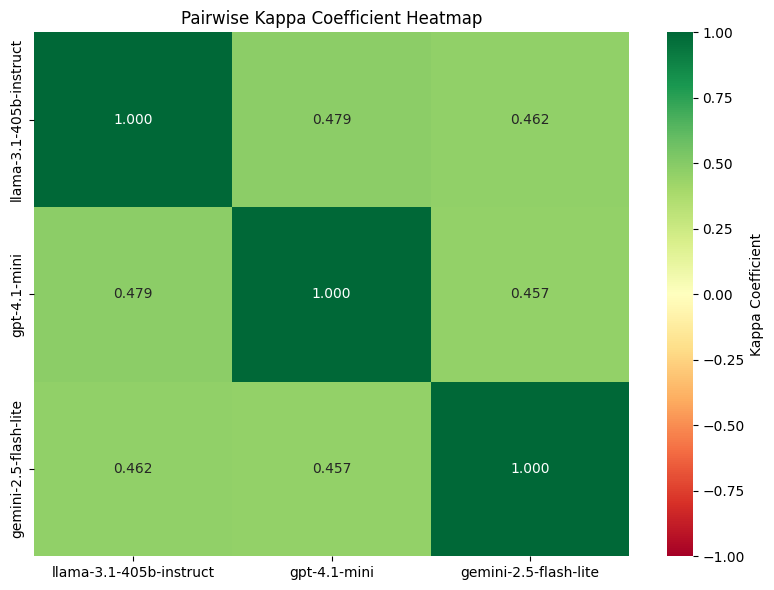

In [68]:
# Step 5: Calculate Kappa coefficient of agreement
from sklearn.metrics import cohen_kappa_score
import itertools

print("\n" + "=" * 80)
print("STEP 5: KAPPA COEFFICIENT OF AGREEMENT")
print("=" * 80)

# Prepare data for kappa calculation
# We need to handle cases where predictions might be missing
prediction_data = []
valid_indices = []

for idx, row in majority_voting_df.iterrows():
    row_predictions = []
    all_valid = True
    
    for model in models:
        pred_col = prediction_cols[model]
        pred = row[pred_col]
        if pd.notna(pred) and str(pred).strip() and not str(pred).startswith('ERROR:'):
            row_predictions.append(str(pred).strip())
        else:
            all_valid = False
            break
    
    if all_valid and len(row_predictions) == len(models):
        prediction_data.append(row_predictions)
        valid_indices.append(idx)

print(f"\nValid records for kappa calculation: {len(prediction_data)}/{len(majority_voting_df)}")

if len(prediction_data) < 2:
    print("⚠️  Not enough valid records for kappa calculation (need at least 2)")
else:
    # Convert to DataFrame for easier handling
    pred_df = pd.DataFrame(prediction_data, columns=models)
    
    # Calculate pairwise kappa coefficients
    print(f"\nPairwise Kappa Coefficients:")
    pairwise_kappas = {}
    
    for i, model1 in enumerate(models):
        for j, model2 in enumerate(models):
            if i < j:
                pred1 = pred_df[model1].tolist()
                pred2 = pred_df[model2].tolist()
                kappa = cohen_kappa_score(pred1, pred2)
                pairwise_kappas[f"{model1} vs {model2}"] = kappa
                print(f"  {model1} vs {model2}: {kappa:.3f}")
    
    # Calculate Fleiss' Kappa (multi-rater agreement)
    # For 3 raters, we can use a simplified approach
    print(f"\nOverall Agreement Analysis:")
    
    # Count agreements
    all_agree = 0
    two_agree = 0
    all_disagree = 0
    
    for row_predictions in prediction_data:
        unique_preds = set(row_predictions)
        if len(unique_preds) == 1:
            all_agree += 1
        elif len(unique_preds) == 2:
            two_agree += 1
        else:
            all_disagree += 1
    
    total = len(prediction_data)
    print(f"  All 3 models agree: {all_agree} ({all_agree/total*100:.1f}%)")
    print(f"  2 models agree: {two_agree} ({two_agree/total*100:.1f}%)")
    print(f"  All 3 disagree: {all_disagree} ({all_disagree/total*100:.1f}%)")
    
    # Average pairwise kappa
    if pairwise_kappas:
        avg_kappa = np.mean(list(pairwise_kappas.values()))
        print(f"\n  Average Pairwise Kappa: {avg_kappa:.3f}")
        
        # Interpret kappa
        if avg_kappa < 0:
            interpretation = "Poor (worse than random)"
        elif avg_kappa < 0.20:
            interpretation = "Slight"
        elif avg_kappa < 0.40:
            interpretation = "Fair"
        elif avg_kappa < 0.60:
            interpretation = "Moderate"
        elif avg_kappa < 0.80:
            interpretation = "Substantial"
        else:
            interpretation = "Almost Perfect"
        
        print(f"  Interpretation: {interpretation}")
    
    # Create agreement heatmap
    if len(models) >= 2:
        kappa_matrix = np.zeros((len(models), len(models)))
        for i, m1 in enumerate(models):
            for j, m2 in enumerate(models):
                if i == j:
                    kappa_matrix[i, j] = 1.0  # Perfect self-agreement
                else:
                    key1 = f"{m1} vs {m2}"
                    key2 = f"{m2} vs {m1}"
                    if key1 in pairwise_kappas:
                        kappa_matrix[i, j] = pairwise_kappas[key1]
                    elif key2 in pairwise_kappas:
                        kappa_matrix[i, j] = pairwise_kappas[key2]
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(kappa_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
                   xticklabels=models, yticklabels=models,
                   vmin=-1, vmax=1, center=0, cbar_kws={'label': 'Kappa Coefficient'})
        plt.title('Pairwise Kappa Coefficient Heatmap')
        plt.tight_layout()
        plt.show()

print("=" * 80)



STEP 6: DISTRIBUTION OF ANALOGY TYPES (MAJORITY VOTING)

Distribution of Analogy Types (from 400 records):
--------------------------------------------------------------------------------
  SIMILARITY                              :  163 ( 40.8%)
  FUNCTION (ROLE / PURPOSE)               :  141 ( 35.2%)
  PART–WHOLE (SUBSYSTEM–SYSTEM)           :   29 (  7.2%)
  TEMPORAL (SEQUENCE / DEVELOPMENT)       :   21 (  5.2%)
  CAUSE–EFFECT (MECHANISM)                :   13 (  3.2%)
  SPATIAL (STRUCTURE / ARRANGEMENT)       :    9 (  2.2%)
  CONTRAST                                :    9 (  2.2%)
  CLASS-INCLUSION (TYPE-OF)               :    8 (  2.0%)
  ATTRIBUTE                               :    7 (  1.8%)


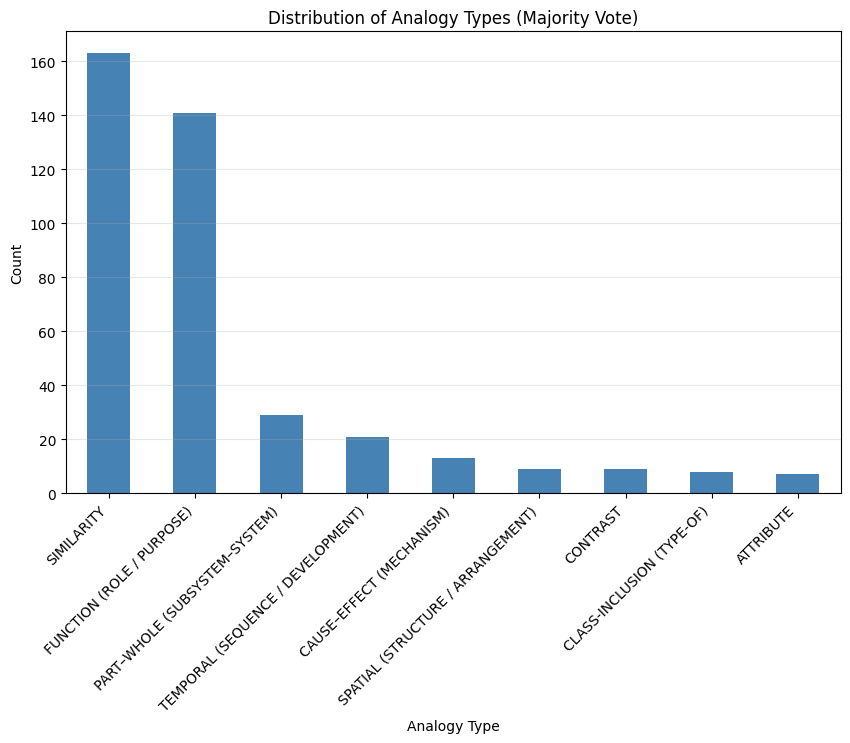

In [ ]:
# Step 6: Show distribution of analogy types from majority voting
print("\n" + "=" * 80)
print("STEP 6: DISTRIBUTION OF ANALOGY TYPES (MAJORITY VOTING)")
print("=" * 80)

# Get distribution of majority votes
majority_dist = majority_voting_df['majority_vote'].value_counts()
total = len(majority_voting_df)

print(f"\nDistribution of Analogy Types (from {total} records):")
print("-" * 80)
for analogy_type, count in majority_dist.items():
    percentage = (count / total) * 100
    print(f"  {analogy_type:40s}: {count:4d} ({percentage:5.1f}%)")


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
majority_dist.plot(kind='bar', color='steelblue')

plt.title("Distribution of Analogy Types (Majority Vote)")
plt.xlabel("Analogy Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Save visualization to vis folder
vis_dir = notebook_dir / "vis" if 'notebook_dir' in dir() else Path.cwd() / "vis"
vis_dir.mkdir(exist_ok=True)
plt.savefig(vis_dir / "distribution_of_analogy_type.png", dpi=300, bbox_inches='tight')
print(f"📊 Saved to: {vis_dir / 'distribution_of_analogy_type.png'}")

plt.show()


# Analogy Type Distribution by Target Subject

This section analyzes how analogy types are distributed across different target subjects (system_a_domain). This helps understand if certain analogy types are more common in specific domains.


In [ ]:
# Analogy Type Distribution by Target Subject (system_a_domain)
print("=" * 80)
print("ANALOGY TYPE DISTRIBUTION BY TARGET SUBJECT")
print("=" * 80)

# Check if majority_voting_df exists, if not try to load from CSV
if 'majority_voting_df' not in globals():
    try:
        # Get notebook directory for relative paths
        notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
        # If running from project root, navigate to RQ4 folder
        if (notebook_dir / "RQ4_Domain_vs_AnalogyType").exists():
            notebook_dir = notebook_dir / "RQ4_Domain_vs_AnalogyType"
        results_path = notebook_dir / "results" / "majority_voting_results.csv"
        majority_voting_df = pd.read_csv(results_path)
        print("✅ Loaded majority voting results from CSV")
    except FileNotFoundError:
        print("⚠️  majority_voting_df not found. Please run the majority voting section first.")
        raise

# Get unique domains
domains = majority_voting_df['system_a_domain'].unique()
print(f"\nFound {len(domains)} unique target subjects (domains)")
print(f"Domains: {', '.join(sorted(domains))}")

# Create cross-tabulation: domain vs analogy type
crosstab = pd.crosstab(majority_voting_df['system_a_domain'], majority_voting_df['majority_vote'])
print(f"\nCross-tabulation shape: {crosstab.shape} (domains × analogy types)")

# Display the cross-tabulation table
print("\n" + "=" * 80)
print("CROSS-TABULATION: Domain × Analogy Type")
print("=" * 80)
print(crosstab)
print("=" * 80)


ANALOGY TYPE DISTRIBUTION BY TARGET SUBJECT

Found 13 unique target subjects (domains)
Domains: Art, Biology, Chemical, Computer, Economy, Engineering, Geography, History, Literature, Mathematics, Philosophy, Physics, Sport

Cross-tabulation shape: (13, 9) (domains × analogy types)

CROSS-TABULATION: Domain × Analogy Type
majority_vote    ATTRIBUTE  CAUSE–EFFECT (MECHANISM)  \
system_a_domain                                        
Art                      0                         1   
Biology                  3                         5   
Chemical                 2                         2   
Computer                 0                         0   
Economy                  0                         0   
Engineering              1                         0   
Geography                0                         2   
History                  1                         0   
Literature               0                         0   
Mathematics              0                         0   
Phil

In [71]:
# Calculate percentages for each domain (normalized by domain)
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

print("\n" + "=" * 80)
print("PERCENTAGE DISTRIBUTION (Normalized by Domain)")
print("=" * 80)
print("Each row sums to 100% - shows proportion of analogy types within each domain")
print("-" * 80)
print(crosstab_pct.round(1))
print("=" * 80)



PERCENTAGE DISTRIBUTION (Normalized by Domain)
Each row sums to 100% - shows proportion of analogy types within each domain
--------------------------------------------------------------------------------
majority_vote    ATTRIBUTE  CAUSE–EFFECT (MECHANISM)  \
system_a_domain                                        
Art                    0.0                       9.1   
Biology                3.0                       5.0   
Chemical               5.4                       5.4   
Computer               0.0                       0.0   
Economy                0.0                       0.0   
Engineering           10.0                       0.0   
Geography              0.0                      10.5   
History                1.7                       0.0   
Literature             0.0                       0.0   
Mathematics            0.0                       0.0   
Philosophy             0.0                       0.0   
Physics                0.0                       6.1   
Sport     


VISUALIZATION 1: HEATMAP - Analogy Types by Domain


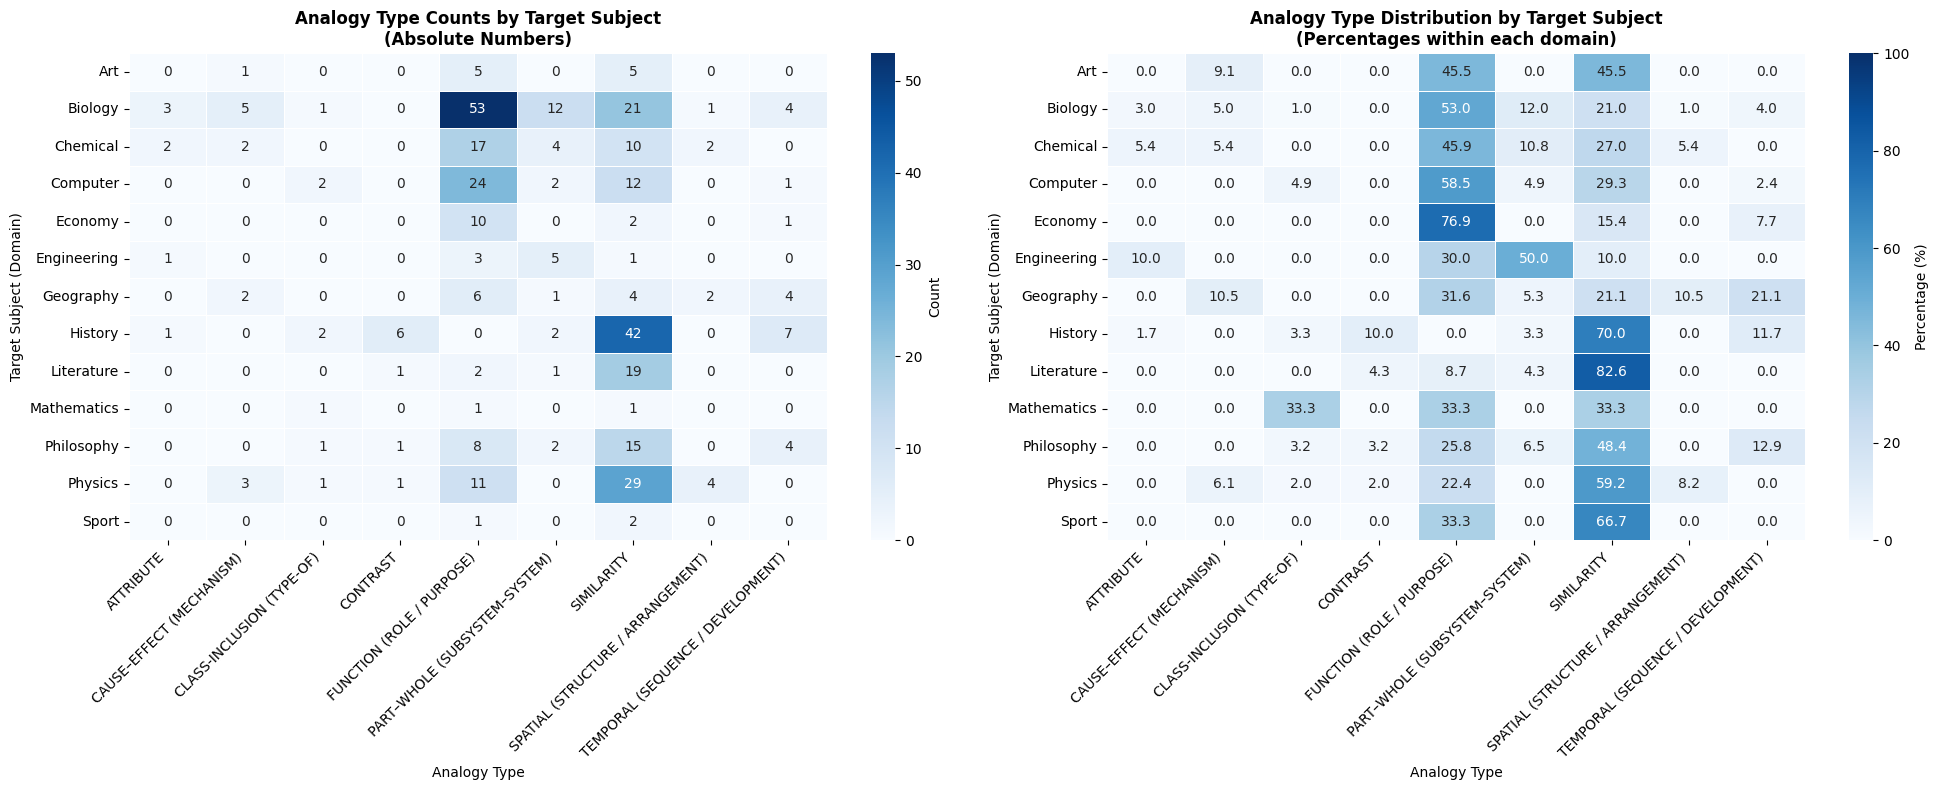

In [ ]:
# Visualization 1: Heatmap of analogy types by domain
print("\n" + "=" * 80)
print("VISUALIZATION 1: HEATMAP - Analogy Types by Domain")
print("=" * 80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, max(8, len(domains) * 0.5)))

# Heatmap of counts - use Blues colormap (steelblue family)
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=ax1,
           cbar_kws={'label': 'Count'}, linewidths=0.5)
ax1.set_title('Analogy Type Counts by Target Subject\n(Absolute Numbers)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Analogy Type', fontsize=10)
ax1.set_ylabel('Target Subject (Domain)', fontsize=10)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Heatmap of percentages - use Blues colormap (steelblue family)
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax2,
           cbar_kws={'label': 'Percentage (%)'}, linewidths=0.5, vmin=0, vmax=100)
ax2.set_title('Analogy Type Distribution by Target Subject\n(Percentages within each domain)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Analogy Type', fontsize=10)
ax2.set_ylabel('Target Subject (Domain)', fontsize=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()

# Save visualization to vis folder
vis_dir = notebook_dir / "vis" if 'notebook_dir' in dir() else Path.cwd() / "vis"
vis_dir.mkdir(exist_ok=True)
plt.savefig(vis_dir / "analogy_type_distribution_according_subject.png", dpi=300, bbox_inches='tight')
print(f"📊 Saved to: {vis_dir / 'analogy_type_distribution_according_subject.png'}")

plt.show()



VISUALIZATION 2: STACKED BAR CHART - Distribution by Domain


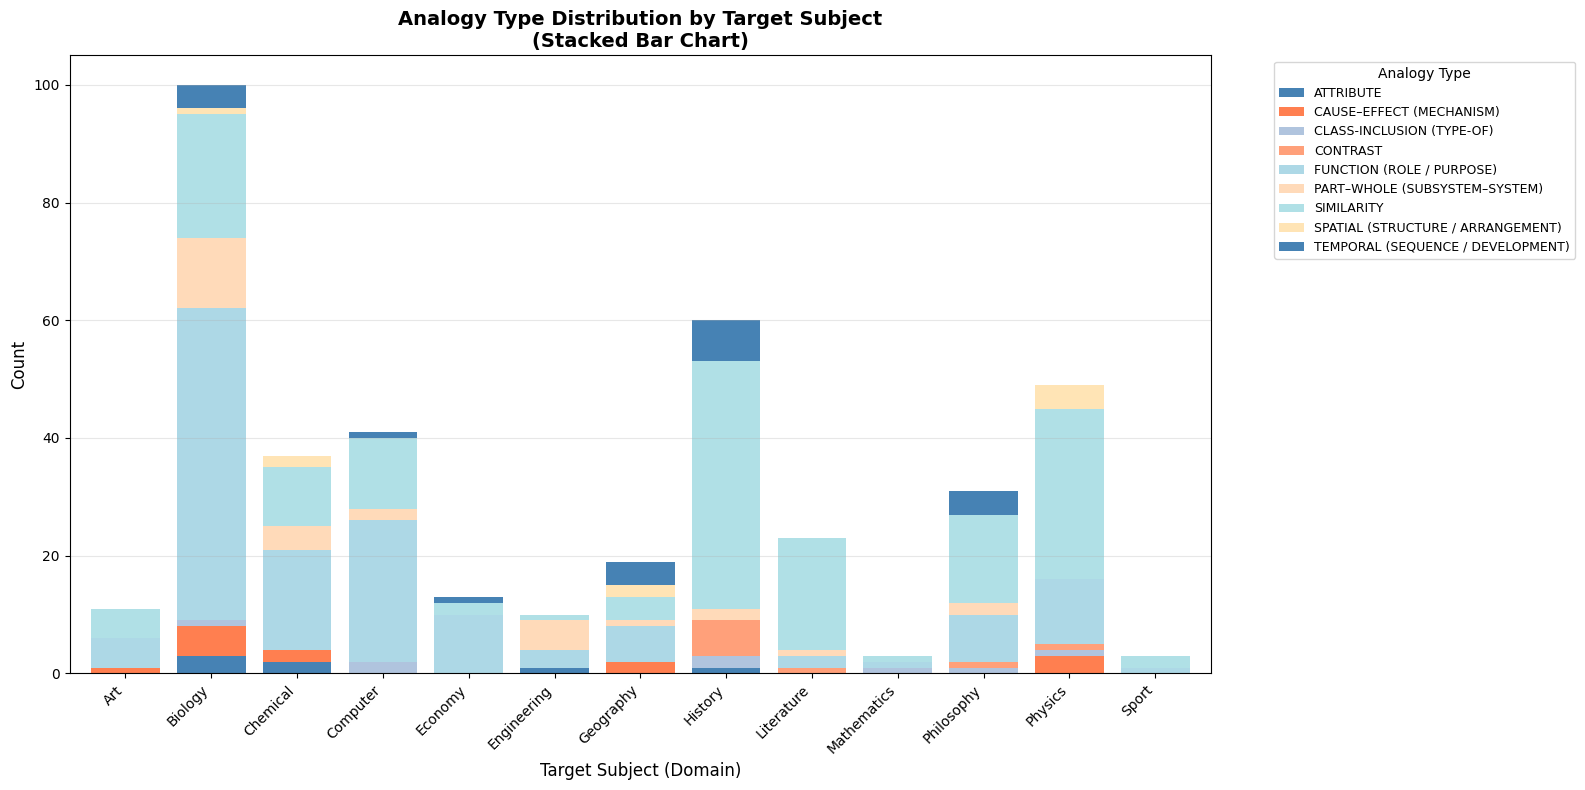

In [ ]:
# Visualization 2: Stacked bar chart showing distribution per domain
print("\n" + "=" * 80)
print("VISUALIZATION 2: STACKED BAR CHART - Distribution by Domain")
print("=" * 80)

fig, ax = plt.subplots(figsize=(16, max(8, len(domains) * 0.6)))

# Hardcoded HIGH CONTRAST color palette (9 analogy types)
# Alternating distinct blues and oranges/corals for maximum differentiation
colors = [
    '#1f4e79',         # 1. ATTRIBUTE - dark navy blue
    '#ff6b35',         # 2. CAUSE-EFFECT - bright orange
    '#5b9bd5',         # 3. CLASS-INCLUSION - medium blue
    '#ffc000',         # 4. CONTRAST - golden yellow
    '#2e75b6',         # 5. FUNCTION - steel blue
    '#ed7d31',         # 6. PART-WHOLE - dark orange
    '#9dc3e6',         # 7. SIMILARITY - light blue
    '#f4a460',         # 8. SPATIAL - sandy brown
    '#203864',         # 9. TEMPORAL - very dark blue
]

# Create stacked bar chart with custom colors
crosstab.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.8)
ax.set_title('Analogy Type Distribution by Target Subject\n(Stacked Bar Chart)', fontsize=14, fontweight='bold')
ax.set_xlabel('Target Subject (Domain)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Analogy Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



VISUALIZATION 3: GROUPED BAR CHART - Comparison Across Domains


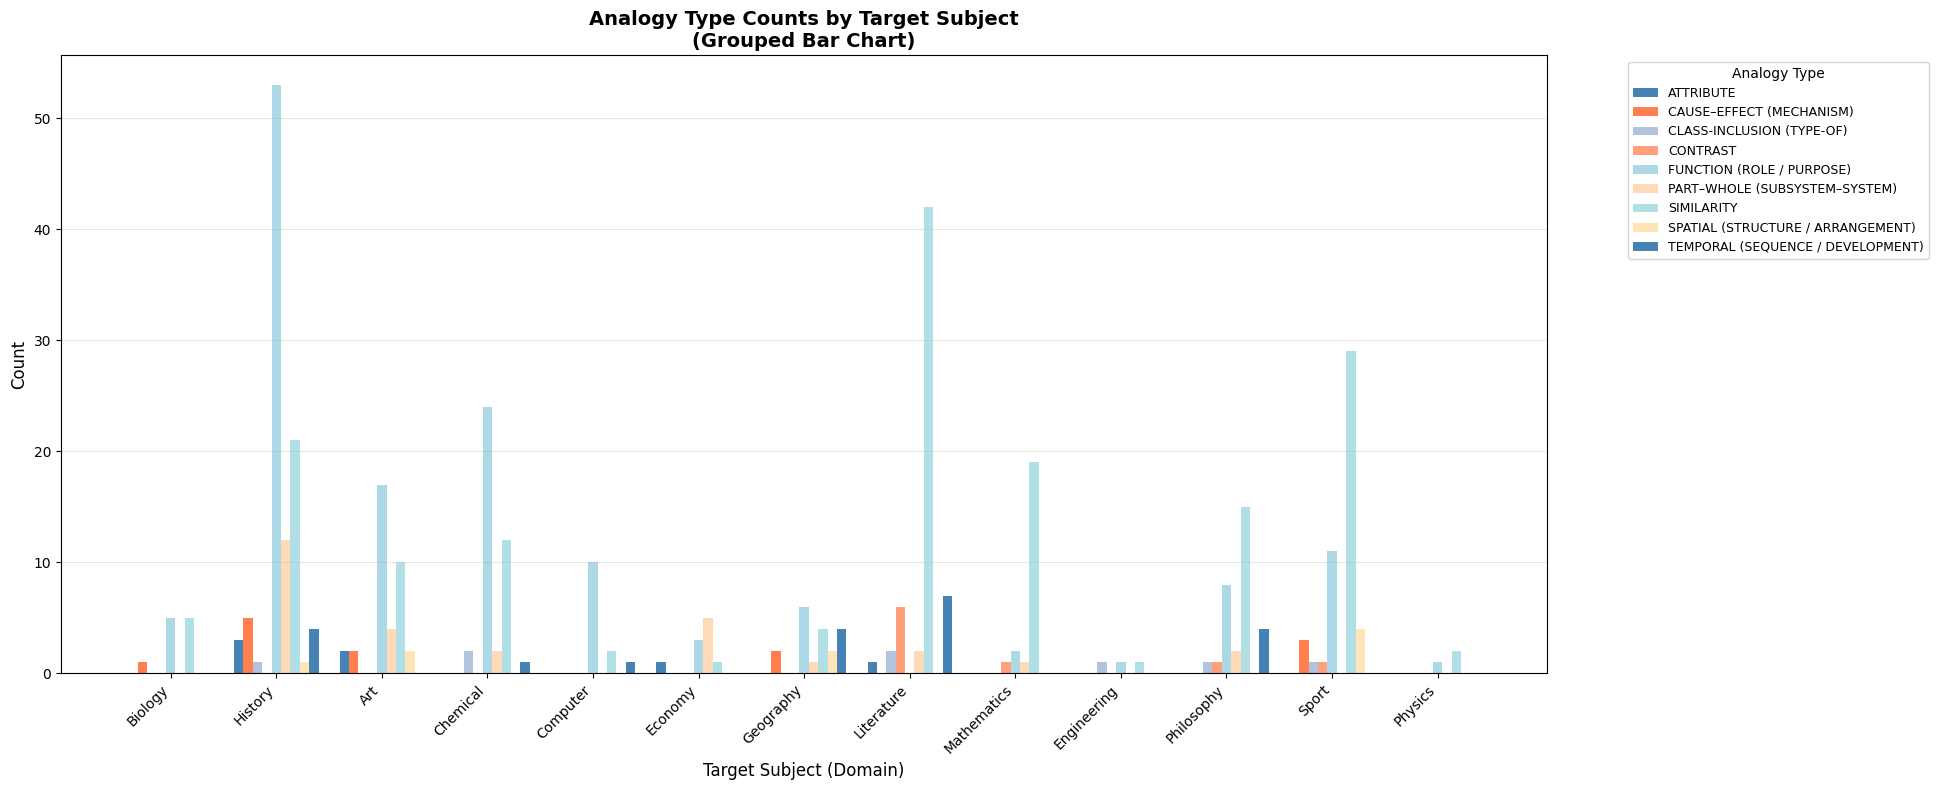

In [ ]:
# Visualization 3: Grouped bar chart for better comparison
print("\n" + "=" * 80)
print("VISUALIZATION 3: GROUPED BAR CHART - Comparison Across Domains")
print("=" * 80)

# Get analogy types
analogy_types = crosstab.columns.tolist()
n_types = len(analogy_types)
n_domains = len(domains)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(max(16, n_domains * 1.5), 8))

x = np.arange(n_domains)
width = 0.8 / n_types  # Width of bars

# Hardcoded HIGH CONTRAST color palette (9 analogy types)
# Alternating distinct blues and oranges/corals for maximum differentiation
colors = [
    '#1f4e79',         # 1. ATTRIBUTE - dark navy blue
    '#ff6b35',         # 2. CAUSE-EFFECT - bright orange
    '#5b9bd5',         # 3. CLASS-INCLUSION - medium blue
    '#ffc000',         # 4. CONTRAST - golden yellow
    '#2e75b6',         # 5. FUNCTION - steel blue
    '#ed7d31',         # 6. PART-WHOLE - dark orange
    '#9dc3e6',         # 7. SIMILARITY - light blue
    '#f4a460',         # 8. SPATIAL - sandy brown
    '#203864',         # 9. TEMPORAL - very dark blue
]

# Create bars for each analogy type
for i, atype in enumerate(analogy_types):
    offset = (i - n_types/2 + 0.5) * width
    bars = ax.bar(x + offset, crosstab[atype], width, label=atype, color=colors[i])

ax.set_xlabel('Target Subject (Domain)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Analogy Type Counts by Target Subject\n(Grouped Bar Chart)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=45, ha='right')
ax.legend(title='Analogy Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



VISUALIZATION 4: PERCENTAGE STACKED BAR CHART


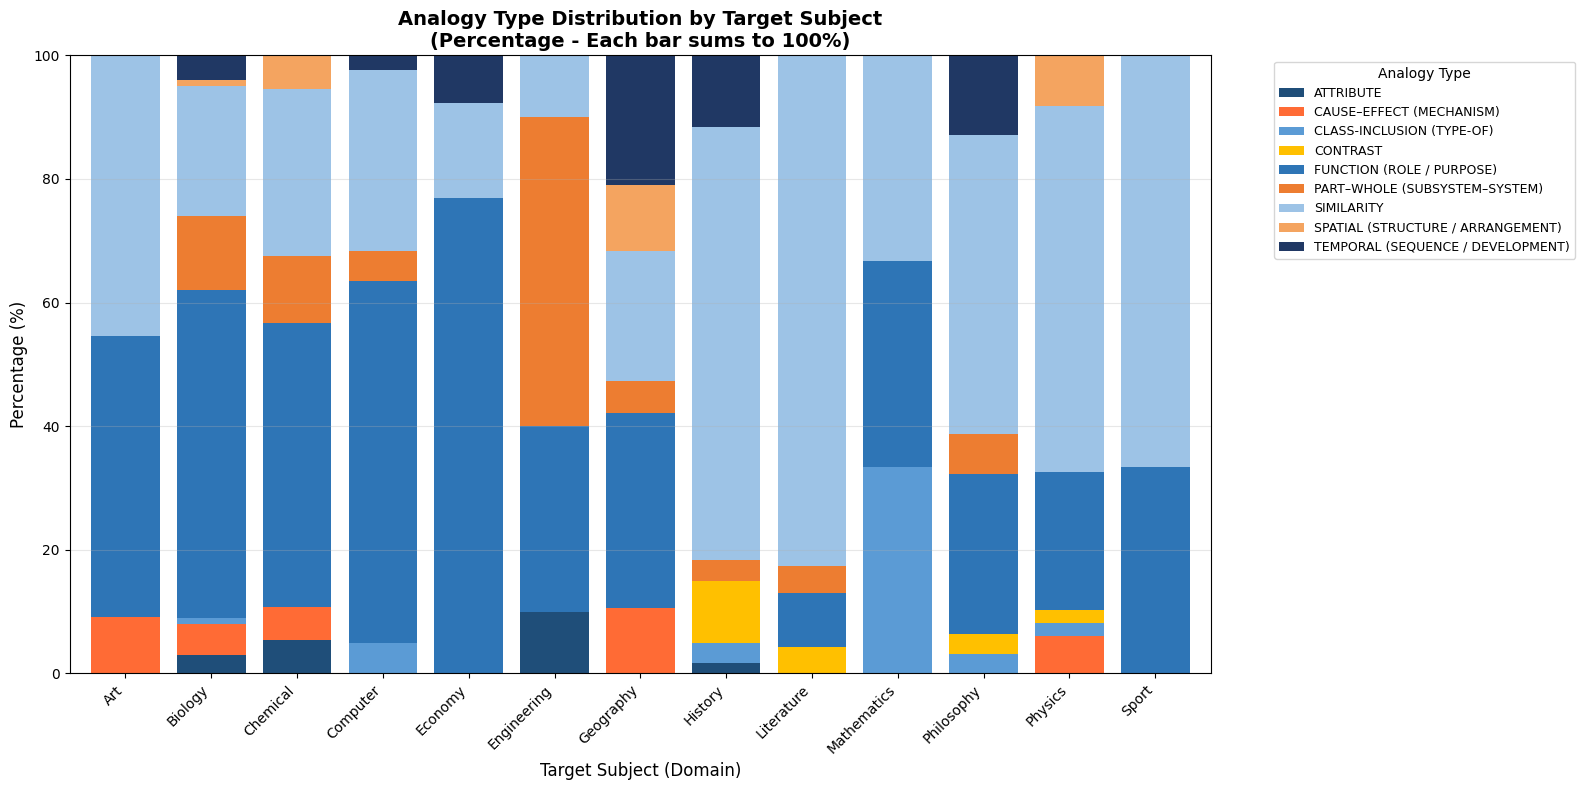

In [83]:
# Visualization 4: Percentage stacked bar chart
print("\n" + "=" * 80)
print("VISUALIZATION 4: PERCENTAGE STACKED BAR CHART")
print("=" * 80)

fig, ax = plt.subplots(figsize=(16, max(8, len(domains) * 0.6)))

# Hardcoded HIGH CONTRAST color palette (9 analogy types)
# Alternating distinct blues and oranges/corals for maximum differentiation
colors = [
    '#1f4e79',         # 1. ATTRIBUTE - dark navy blue
    '#ff6b35',         # 2. CAUSE-EFFECT - bright orange
    '#5b9bd5',         # 3. CLASS-INCLUSION - medium blue
    '#ffc000',         # 4. CONTRAST - golden yellow
    '#2e75b6',         # 5. FUNCTION - steel blue
    '#ed7d31',         # 6. PART-WHOLE - dark orange
    '#9dc3e6',         # 7. SIMILARITY - light blue
    '#f4a460',         # 8. SPATIAL - sandy brown
    '#203864',         # 9. TEMPORAL - very dark blue
]

# Create percentage stacked bar chart with custom colors
crosstab_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.8)
ax.set_title('Analogy Type Distribution by Target Subject\n(Percentage - Each bar sums to 100%)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Target Subject (Domain)', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim(0, 100)
ax.legend(title='Analogy Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [76]:
# Statistical Summary: Most common analogy type per domain
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)

print("\nMost Common Analogy Type per Domain:")
print("-" * 80)
for domain in domains:
    domain_data = crosstab.loc[domain]
    most_common = domain_data.idxmax()
    count = domain_data.max()
    total = domain_data.sum()
    percentage = (count / total * 100) if total > 0 else 0
    print(f"  {domain:20s}: {most_common:40s} ({count}/{total} = {percentage:5.1f}%)")

# Overall distribution for comparison
print("\n" + "-" * 80)
print("Overall Distribution (All Domains Combined):")
overall_dist = majority_voting_df['majority_vote'].value_counts()
total_all = len(majority_voting_df)
for atype, count in overall_dist.items():
    pct = (count / total_all * 100)
    print(f"  {atype:40s}: {count:4d} ({pct:5.1f}%)")

# Domain-specific insights
print("\n" + "-" * 80)
print("Domain-Specific Insights:")
print("-" * 80)

# Find domains with unusual distributions
for domain in domains:
    domain_data = crosstab.loc[domain]
    domain_pct = crosstab_pct.loc[domain]
    
    # Find analogy types that are overrepresented in this domain
    overall_pct = (overall_dist / total_all * 100)
    
    overrepresented = []
    for atype in domain_data.index:
        if domain_data[atype] > 0:
            domain_pct_val = domain_pct[atype]
            overall_pct_val = overall_pct.get(atype, 0)
            if domain_pct_val > overall_pct_val * 1.5:  # 50% more than overall
                overrepresented.append((atype, domain_pct_val, overall_pct_val))
    
    if overrepresented:
        print(f"\n  {domain}:")
        for atype, dom_pct, ovr_pct in overrepresented:
            print(f"    - {atype}: {dom_pct:.1f}% in domain vs {ovr_pct:.1f}% overall "
                  f"({dom_pct/ovr_pct if ovr_pct > 0 else 0:.1f}x more common)")

print("\n" + "=" * 80)
print("✅ Analysis complete!")
print("=" * 80)



STATISTICAL SUMMARY

Most Common Analogy Type per Domain:
--------------------------------------------------------------------------------
  Biology             : FUNCTION (ROLE / PURPOSE)                (53/100 =  53.0%)
  History             : SIMILARITY                               (42/60 =  70.0%)
  Art                 : FUNCTION (ROLE / PURPOSE)                (5/11 =  45.5%)
  Chemical            : FUNCTION (ROLE / PURPOSE)                (17/37 =  45.9%)
  Computer            : FUNCTION (ROLE / PURPOSE)                (24/41 =  58.5%)
  Economy             : FUNCTION (ROLE / PURPOSE)                (10/13 =  76.9%)
  Geography           : FUNCTION (ROLE / PURPOSE)                (6/19 =  31.6%)
  Literature          : SIMILARITY                               (19/23 =  82.6%)
  Mathematics         : CLASS-INCLUSION (TYPE-OF)                (1/3 =  33.3%)
  Engineering         : PART–WHOLE (SUBSYSTEM–SYSTEM)            (5/10 =  50.0%)
  Philosophy          : SIMILARITY          

# Analogy Type Difficulty Analysis: Agreement-Based Ease of Finding

This section analyzes which analogy types are easiest to find based on LLM agreement. Higher agreement among the 3 LLMs indicates that the analogy type is more straightforward and easier to identify consistently.


In [ ]:
# Calculate agreement rates per analogy type
print("=" * 80)
print("ANALOGY TYPE DIFFICULTY: AGREEMENT-BASED ANALYSIS")
print("=" * 80)

# Check if majority_voting_df exists, if not try to load from CSV
if 'majority_voting_df' not in globals():
    try:
        # Get notebook directory for relative paths
        notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
        # If running from project root, navigate to RQ4 folder
        if (notebook_dir / "RQ4_Domain_vs_AnalogyType").exists():
            notebook_dir = notebook_dir / "RQ4_Domain_vs_AnalogyType"
        results_path = notebook_dir / "results" / "majority_voting_results.csv"
        majority_voting_df = pd.read_csv(results_path)
        print("✅ Loaded majority voting results from CSV")
    except FileNotFoundError:
        print("⚠️  majority_voting_df not found. Please run the majority voting section first.")
        raise

# Get model prediction columns
models = ["llama-3.1-405b-instruct", "gpt-4.1-mini", "gemini-2.5-flash-lite"]
prediction_cols = {}
for model in models:
    model_key = model.replace('.', '_').replace('-', '_')
    prediction_cols[model] = f'{model_key}_prediction'

# Calculate agreement statistics for each analogy type
agreement_stats = []

for analogy_type in majority_voting_df['majority_vote'].unique():
    if pd.isna(analogy_type) or analogy_type == '':
        continue
    
    # Get all records with this analogy type
    type_records = majority_voting_df[majority_voting_df['majority_vote'] == analogy_type]
    
    all_agree_count = 0
    two_agree_count = 0
    all_disagree_count = 0
    total_count = len(type_records)
    
    for _, row in type_records.iterrows():
        predictions = {}
        for model in models:
            pred_col = prediction_cols[model]
            pred = row[pred_col]
            if pd.notna(pred) and str(pred).strip() and not str(pred).startswith('ERROR:'):
                predictions[model] = str(pred).strip()
        
        if len(predictions) < 2:
            continue
        
        unique_preds = set(predictions.values())
        
        if len(unique_preds) == 1:
            all_agree_count += 1
        elif len(unique_preds) == 2:
            two_agree_count += 1
        else:
            all_disagree_count += 1
    
    # Calculate agreement rate (all 3 agree)
    agreement_rate = (all_agree_count / total_count * 100) if total_count > 0 else 0
    majority_agreement_rate = ((all_agree_count + two_agree_count) / total_count * 100) if total_count > 0 else 0
    
    agreement_stats.append({
        'analogy_type': analogy_type,
        'total_count': total_count,
        'all_agree_count': all_agree_count,
        'two_agree_count': two_agree_count,
        'all_disagree_count': all_disagree_count,
        'agreement_rate': agreement_rate,  # All 3 agree
        'majority_agreement_rate': majority_agreement_rate  # At least 2 agree
    })

# Convert to DataFrame and sort by agreement rate (easiest first)
agreement_df = pd.DataFrame(agreement_stats)
agreement_df = agreement_df.sort_values('agreement_rate', ascending=False)

print(f"\nAgreement Statistics by Analogy Type:")
print("-" * 80)
print(f"{'Analogy Type':<45} {'Total':<8} {'All Agree':<12} {'2 Agree':<10} {'All Disagree':<15} {'Agreement %':<12}")
print("-" * 80)
for _, row in agreement_df.iterrows():
    print(f"{row['analogy_type']:<45} {row['total_count']:<8} {row['all_agree_count']:<12} "
          f"{row['two_agree_count']:<10} {row['all_disagree_count']:<15} {row['agreement_rate']:<12.1f}")

print("\n" + "=" * 80)
print("Interpretation: Higher agreement rate = Easier to find/identify")
print("=" * 80)


ANALOGY TYPE DIFFICULTY: AGREEMENT-BASED ANALYSIS

Agreement Statistics by Analogy Type:
--------------------------------------------------------------------------------
Analogy Type                                  Total    All Agree    2 Agree    All Disagree    Agreement % 
--------------------------------------------------------------------------------
FUNCTION (ROLE / PURPOSE)                     141      85           53         3               60.3        
TEMPORAL (SEQUENCE / DEVELOPMENT)             21       10           9          2               47.6        
CAUSE–EFFECT (MECHANISM)                      13       6            4          3               46.2        
SIMILARITY                                    163      75           74         14              46.0        
CONTRAST                                      9        3            4          2               33.3        
SPATIAL (STRUCTURE / ARRANGEMENT)             9        2            6          1               22.2  


VISUALIZATION: AGREEMENT RATE BY ANALOGY TYPE
Higher agreement = Easier to find/identify consistently across LLMs


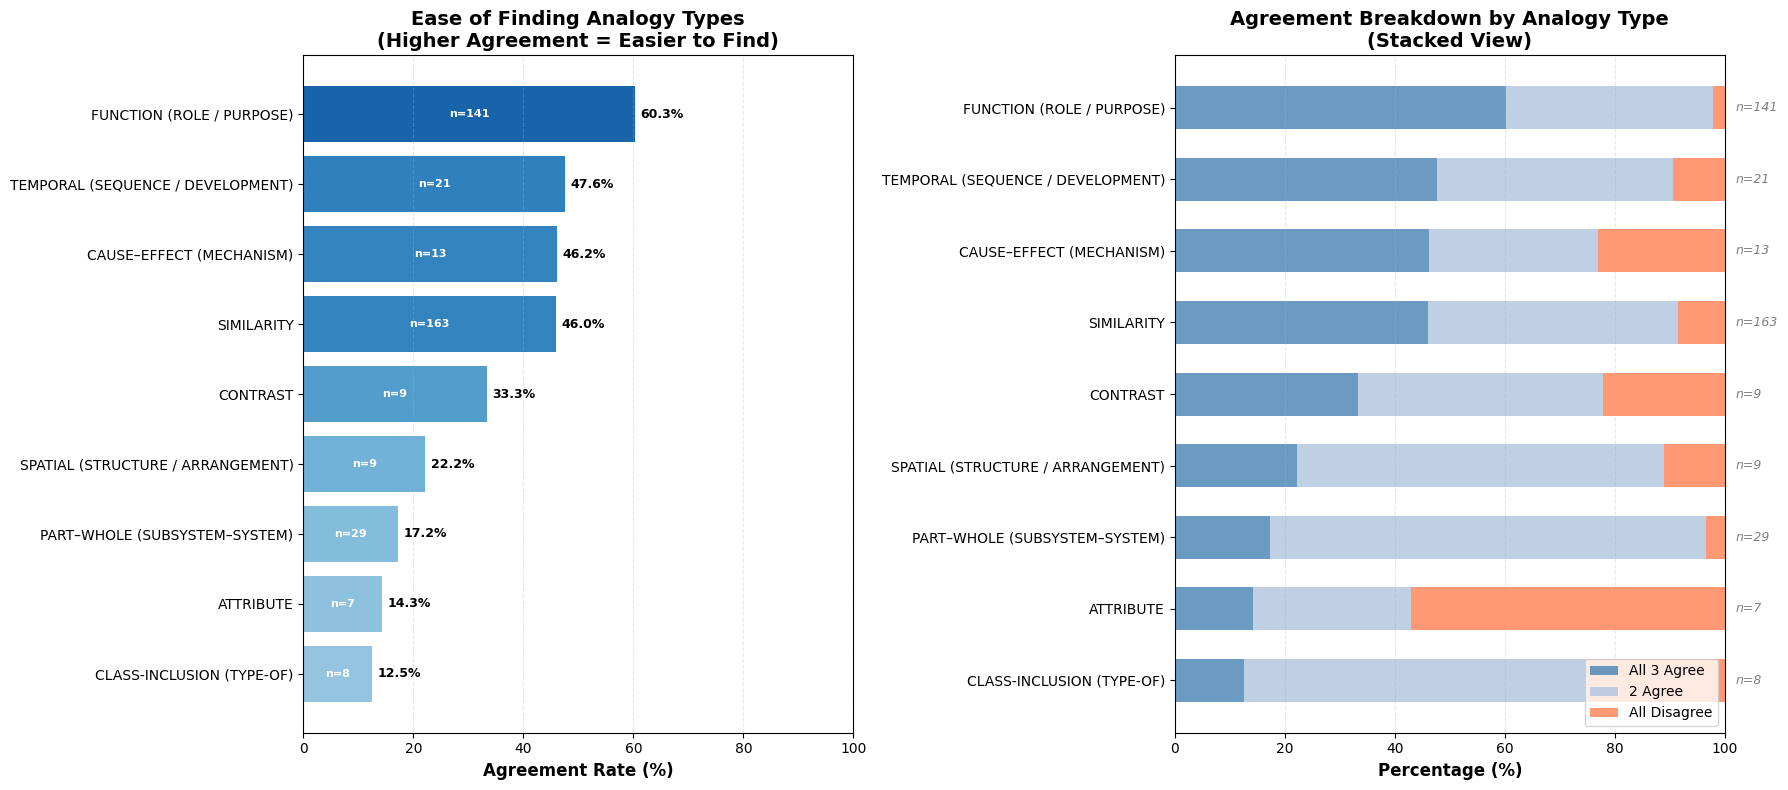


📊 Summary:
  Easiest to find (highest agreement): FUNCTION (ROLE / PURPOSE) (60.3% agreement)
  Hardest to find (lowest agreement): CLASS-INCLUSION (TYPE-OF) (12.5% agreement)
  Average agreement rate: 33.3%
  Median agreement rate: 33.3%


In [ ]:
# Visualization: Agreement Rate by Analogy Type (Ease of Finding)
print("\n" + "=" * 80)
print("VISUALIZATION: AGREEMENT RATE BY ANALOGY TYPE")
print("=" * 80)
print("Higher agreement = Easier to find/identify consistently across LLMs")
print("=" * 80)

# Set consistent color scheme matching project style
COLOR_STEELBLUE = 'steelblue'
COLOR_CORAL = 'coral'

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Bar chart of agreement rates (sorted)
# Use gradient from steelblue (high agreement) to lightsteelblue (low agreement)
n_bars = len(agreement_df)
max_rate = agreement_df['agreement_rate'].max()
min_rate = agreement_df['agreement_rate'].min()

# Create color gradient using Blues colormap (steelblue family)
# Higher agreement = darker blue (steelblue), lower agreement = lighter blue
colors_list = []
for rate in agreement_df['agreement_rate']:
    # Normalize rate to 0-1 scale for colormap
    if max_rate > min_rate:
        normalized = (rate - min_rate) / (max_rate - min_rate)
        # Use Blues colormap: 0.4-0.8 range gives nice steelblue to lightsteelblue gradient
        colormap_val = 0.4 + normalized * 0.4
    else:
        colormap_val = 0.6  # Default to medium blue
    colors_list.append(plt.cm.Blues(colormap_val))

bars = ax1.barh(range(n_bars), agreement_df['agreement_rate'], color=colors_list)
ax1.set_yticks(range(n_bars))
ax1.set_yticklabels(agreement_df['analogy_type'], fontsize=10)
ax1.set_xlabel('Agreement Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Ease of Finding Analogy Types\n(Higher Agreement = Easier to Find)', 
              fontsize=14, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.invert_yaxis()  # Show highest at top

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, agreement_df['agreement_rate'])):
    width = bar.get_width()
    ax1.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold')

# Add count labels
for i, (bar, count) in enumerate(zip(bars, agreement_df['total_count'])):
    ax1.text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, 
            f'n={count}', ha='center', va='center', fontsize=8, 
            color='white', fontweight='bold')

# Plot 2: Stacked bar chart showing agreement breakdown
x_pos = np.arange(len(agreement_df))
width = 0.6

# Calculate percentages for stacking
all_agree_pct = agreement_df['all_agree_count'] / agreement_df['total_count'] * 100
two_agree_pct = agreement_df['two_agree_count'] / agreement_df['total_count'] * 100
all_disagree_pct = agreement_df['all_disagree_count'] / agreement_df['total_count'] * 100

# Use project color scheme: steelblue for good agreement, coral for disagreement
bars1 = ax2.barh(x_pos, all_agree_pct, width, label='All 3 Agree', color=COLOR_STEELBLUE, alpha=0.8)
bars2 = ax2.barh(x_pos, two_agree_pct, width, left=all_agree_pct, 
                 label='2 Agree', color='lightsteelblue', alpha=0.8)
bars3 = ax2.barh(x_pos, all_disagree_pct, width, 
                 left=all_agree_pct + two_agree_pct, 
                 label='All Disagree', color=COLOR_CORAL, alpha=0.8)

ax2.set_yticks(x_pos)
ax2.set_yticklabels(agreement_df['analogy_type'], fontsize=10)
ax2.set_xlabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Agreement Breakdown by Analogy Type\n(Stacked View)', 
              fontsize=14, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.invert_yaxis()

# Add total count labels on the right
for i, count in enumerate(agreement_df['total_count']):
    ax2.text(102, i, f'n={count}', ha='left', va='center', fontsize=9, 
            style='italic', color='gray')

plt.tight_layout()

# Save visualization to vis folder
vis_dir = notebook_dir / "vis" if 'notebook_dir' in dir() else Path.cwd() / "vis"
vis_dir.mkdir(exist_ok=True)
plt.savefig(vis_dir / "ease_of_finding_analogy_type.png", dpi=300, bbox_inches='tight')
print(f"📊 Saved to: {vis_dir / 'ease_of_finding_analogy_type.png'}")

plt.show()

# Summary statistics
print(f"\n📊 Summary:")
print(f"  Easiest to find (highest agreement): {agreement_df.iloc[0]['analogy_type']} "
      f"({agreement_df.iloc[0]['agreement_rate']:.1f}% agreement)")
print(f"  Hardest to find (lowest agreement): {agreement_df.iloc[-1]['analogy_type']} "
      f"({agreement_df.iloc[-1]['agreement_rate']:.1f}% agreement)")
print(f"  Average agreement rate: {agreement_df['agreement_rate'].mean():.1f}%")
print(f"  Median agreement rate: {agreement_df['agreement_rate'].median():.1f}%")
print("=" * 80)
